import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

def pdf_S(s):
    """Exact piecewise PDF of the sum of 4 U(0.5, 5) random variables."""
    s = np.asarray(s)
    f = np.zeros_like(s, dtype=float)
    
    # Range 1: 2 to 6.5
    mask1 = (s >= 2) & (s <= 6.5)
    f[mask1] = (1/27) * ((s[mask1] - 2) / 4.5)**3
    
    # Range 2: 6.5 to 11
    mask2 = (s > 6.5) & (s <= 11)
    f[mask2] = (1/27) * (((s[mask2] - 2) / 4.5)**3 - 4 * ((s[mask2] - 6.5) / 4.5)**3)
    
    # Range 3: 11 to 15.5
    mask3 = (s > 11) & (s <= 15.5)
    f[mask3] = (1/27) * (((20 - s[mask3]) / 4.5)**3 - 4 * ((15.5 - s[mask3]) / 4.5)**3)
    
    # Range 4: 15.5 to 20
    mask4 = (s > 15.5) & (s <= 20)
    f[mask4] = (1/27) * ((20 - s[mask4]) / 4.5)**3
    
    return f

# Generate X values for plotting
s_vals = np.linspace(0, 22, 1000)

# Evaluate PDF
pdf_vals = pdf_S(s_vals)

# Evaluate CDF via fast cumulative trapezoidal integration
cdf_vals = integrate.cumulative_trapezoid(pdf_vals, s_vals, initial=0)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution of Signal Length (Sum of 4 Uniform[0.5, 5] Variables)', fontsize=14)

# PDF Plot
ax1.plot(s_vals, pdf_vals, color='blue', linewidth=2)
ax1.fill_between(s_vals, pdf_vals, alpha=0.2, color='blue')
ax1.axvline(11, color='red', linestyle='--', alpha=0.5, label=r'Mean ($\mu=11$)')
ax1.set_title('Probability Density Function (PDF)')
ax1.set_xlabel('Signal Length (seconds)')
ax1.set_ylabel(r'Density $f_S(s)$')
ax1.set_xlim(0, 22)
ax1.grid(True, alpha=0.3)
ax1.legend()

# CDF Plot
ax2.plot(s_vals, cdf_vals, color='green', linewidth=2)
ax2.axvline(11, color='red', linestyle='--', alpha=0.5, label=r'Mean ($\mu=11$)')
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.8)
ax2.set_title('Cumulative Distribution Function (CDF)')
ax2.set_xlabel('Signal Length (seconds)')
ax2.set_ylabel(r'Probability $P(S \leq s)$')
ax2.set_xlim(0, 22)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1747133/497360253.py:52: SyntaxWarning: invalid escape sequence '\m'
  ax1.axvline(mu_S, color='red', linestyle=':', alpha=0.5, label=f'Mean ($\mu$={mu_S})')
/tmp/ipykernel_1747133/497360253.py:63: SyntaxWarning: invalid escape sequence '\m'
  ax2.axvline(mu_S, color='red', linestyle=':', alpha=0.5, label=f'Mean ($\mu$={mu_S})')


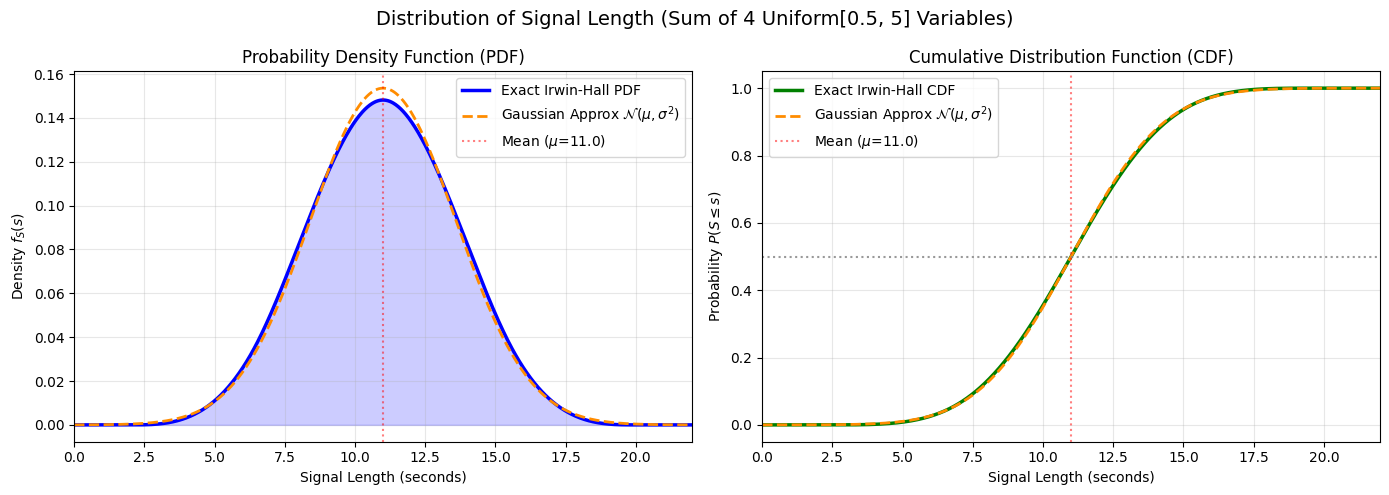

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats

def pdf_S(s):
    """Exact piecewise PDF of the sum of 4 U(0.5, 5) random variables."""
    s = np.asarray(s)
    f = np.zeros_like(s, dtype=float)
    
    mask1 = (s >= 2) & (s <= 6.5)
    f[mask1] = (1/27) * ((s[mask1] - 2) / 4.5)**3
    
    mask2 = (s > 6.5) & (s <= 11)
    f[mask2] = (1/27) * (((s[mask2] - 2) / 4.5)**3 - 4 * ((s[mask2] - 6.5) / 4.5)**3)
    
    mask3 = (s > 11) & (s <= 15.5)
    f[mask3] = (1/27) * (((20 - s[mask3]) / 4.5)**3 - 4 * ((15.5 - s[mask3]) / 4.5)**3)
    
    mask4 = (s > 15.5) & (s <= 20)
    f[mask4] = (1/27) * ((20 - s[mask4]) / 4.5)**3
    
    return f

# Generate X values for plotting
s_vals = np.linspace(0, 22, 1000)

# Evaluate PDF
pdf_vals = pdf_S(s_vals)

# Evaluate CDF via fast cumulative trapezoidal integration
cdf_vals = integrate.cumulative_trapezoid(pdf_vals, s_vals, initial=0)

# --- Compute Gaussian Approximation ---
# True moments of S = sum of 4 * U(0.5, 5.0)
mu_X = (0.5 + 5.0) / 2
var_X = (5.0 - 0.5)**2 / 12
mu_S = 4 * mu_X
var_S = 4 * var_X
std_S = np.sqrt(var_S)

gaussian_pdf = stats.norm.pdf(s_vals, loc=mu_S, scale=std_S)
gaussian_cdf = stats.norm.cdf(s_vals, loc=mu_S, scale=std_S)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Signal Length (Sum of 4 Uniform[0.5, 5] Variables)', fontsize=14)

# PDF Plot
ax1.plot(s_vals, pdf_vals, color='blue', linewidth=2.5, label='Exact Irwin-Hall PDF')
ax1.fill_between(s_vals, pdf_vals, alpha=0.2, color='blue')
ax1.plot(s_vals, gaussian_pdf, color='darkorange', linestyle='--', linewidth=2, label=r'Gaussian Approx $\mathcal{N}(\mu, \sigma^2)$')
ax1.axvline(mu_S, color='red', linestyle=':', alpha=0.5, label=f'Mean ($\mu$={mu_S})')
ax1.set_title('Probability Density Function (PDF)')
ax1.set_xlabel('Signal Length (seconds)')
ax1.set_ylabel(r'Density $f_S(s)$')
ax1.set_xlim(0, 22)
ax1.grid(True, alpha=0.3)
ax1.legend()

# CDF Plot
ax2.plot(s_vals, cdf_vals, color='green', linewidth=2.5, label='Exact Irwin-Hall CDF')
ax2.plot(s_vals, gaussian_cdf, color='darkorange', linestyle='--', linewidth=2, label=r'Gaussian Approx $\mathcal{N}(\mu, \sigma^2)$')
ax2.axvline(mu_S, color='red', linestyle=':', alpha=0.5, label=f'Mean ($\mu$={mu_S})')
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.8)
ax2.set_title('Cumulative Distribution Function (CDF)')
ax2.set_xlabel('Signal Length (seconds)')
ax2.set_ylabel(r'Probability $P(S \leq s)$')
ax2.set_xlim(0, 22)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [7]:
# --- Statistical Summary ---
# Calculate continuous statistics of the sum S mathematically
mu_X = (0.5 + 5.0) / 2
var_X = (5.0 - 0.5)**2 / 12
std_X = np.sqrt(var_X)

mu_S = 4 * mu_X
var_S = 4 * var_X
std_S = np.sqrt(var_S)

# The sum of symmetric distributions is symmetric, so Skewness is 0
skew_S = 0.0

# Kurtosis of Uniform = -6/5 = -1.2
# Kurtosis of sum of n i.i.d variables = kurtosis_X / n
kurt_X = -1.2
kurt_S = kurt_X / 4

print("=== Theoretical Statistics of S (Sum of 4 U[0.5, 5.0]) ===")
print(f"Number of segments (N)   : {4}")
print(f"Segment Mean (μ_X)       : {mu_X:.4f} s")
print(f"Segment Variance (σ_X²)  : {var_X:.4f} s²\n")

print(f"1st Moment (Mean μ_S)    : {mu_S:.4f} s")
print(f"2nd Moment (Variance σ_S²): {var_S:.4f} s²")
print(f"Standard Deviation (σ_S) : {std_S:.4f} s")
print(f"3rd Moment (Skewness)    : {skew_S:.4f}")
print(f"4th Moment (Excess Kurt.): {kurt_S:.4f}")
print(f"4th Moment (Real Kurt.)  : {kurt_S + 3.0:.4f}")
print(f"Support Range [min, max] : [2.0000, 20.0000] s")

# Compute 1st, 5th, 95th, 99th percentiles via the CDF
def get_percentile(cdf_vals, s_vals, p):
    return s_vals[np.argmax(cdf_vals >= p)]

p01 = get_percentile(cdf_vals, s_vals, 0.01)
p05 = get_percentile(cdf_vals, s_vals, 0.05)
p95 = get_percentile(cdf_vals, s_vals, 0.95)
p99 = get_percentile(cdf_vals, s_vals, 0.99)

print("\n=== Important Percentiles (from exact CDF) ===")
print(f" 1st Percentile: ~{p01:.2f} s")
print(f" 5th Percentile: ~{p05:.2f} s")
print(f"95th Percentile: ~{p95:.2f} s")
print(f"99th Percentile: ~{p99:.2f} s")

=== Theoretical Statistics of S (Sum of 4 U[0.5, 5.0]) ===
Number of segments (N)   : 4
Segment Mean (μ_X)       : 2.7500 s
Segment Variance (σ_X²)  : 1.6875 s²

1st Moment (Mean μ_S)    : 11.0000 s
2nd Moment (Variance σ_S²): 6.7500 s²
Standard Deviation (σ_S) : 2.5981 s
3rd Moment (Skewness)    : 0.0000
4th Moment (Excess Kurt.): -0.3000
4th Moment (Real Kurt.)  : 2.7000
Support Range [min, max] : [2.0000, 20.0000] s

=== Important Percentiles (from exact CDF) ===
 1st Percentile: ~5.15 s
 5th Percentile: ~6.72 s
95th Percentile: ~15.31 s
99th Percentile: ~16.87 s


In [2]:
from utilities import randdir

A = randdir((4,0), device='cpu')
print(A @ A.mH)

tensor([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]], dtype=torch.complex128)
